# Transformer 번역기 (학습 노드)

한글 폰트 필요할때 실행시키기

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '~work/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')
mpl.font_manager.findfont(font)

print("슝=3")

슝=3


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)

2.7.1+cu118


**positional encoding**

In [3]:

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


**Multi-Head Attention**

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model) 

    # 단어가 서로 얼마나 관련 있는지
    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1) # K.size(-1)은 K 텐서 마지막 차원 크기 depth
        QK = torch.matmul(Q, K.transpose(-2, -1)) #Q k 곱해서 점수 계산
        # 학습이 잘 되도록 크기 조절해줌
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # scaled_qk: Attention을 위한 Softmax 직전의 Scaled QK
        # 마스킹된 부분에 음수를 더해서 소프트맥스 결과가 0이 되게 만들기
        if mask is not None: 
            scaled_qk += (mask * -1e9)
        # 소프트맥스로 점수를 0-1 사이로 바꾸기
        attentions = F.softmax(scaled_qk, dim=-1)
        # 확률만큼 가중치 둬서 v 가져오기
        out = torch.matmul(attentions, V)

        return out, attentions
    # 쪼개서 각각 보게 만들기
    def split_heads(self, x):
        batch_size = x.size(0)
        # 모양 바꾸기 (Batch, Seq_len, Num_Heads, Depth)로 쪼개기
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        # 순서 바꿔서 계산하기 편하게 하기(Batch, Num_Heads, Seq_len, Depth)
        # seq_len, depth끼리 있을때 가장 빠르기 때문에 num_heads를 앞으로 보내기
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        # 원래 입력과 같이 순서 다시 바꿔주기(batch, seq_len, num_heae, depth) 형태로
        x = x.permute(0, 2, 1, 3)
        # 다시 합치기 num_head랑 depth 하나로 합쳐서 d_model로 만듦
        # contiguous()는 순서대로 다시 정렬해주는 작업
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)
        print(f"1. Linear 통과 후 (WQ): {WQ.shape}")

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)
        print(f"2. 헤드 쪼갠 후 (WQ_splits): {WQ_splits.shape}")

        # 각각 집중할 단어 찾기
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)
        print(f"3. 어텐션 결과 (out): {out.shape}")
        print(f"4. 어텐션 확률 분포 (weights): {attention_weights.shape}")


        # 결과물 합치기
        out = self.combine_heads(out)
        print(f"5. 다시 합친 후 (combined): {out.shape}")
        
        out = self.linear(out)
        print(f"6. 최종 출력 모양: {out.shape}")

        return out, attention_weights

출력해보기

In [5]:
# Batch_size=2(문장 2개), Seq_len=4(단어 4개), D_model=128(단어당 숫자 128개)
test_Q = torch.randn(2, 4, 128)
test_K = torch.randn(2, 4, 128)
test_V = torch.randn(2, 4, 128)

# 모델 생성 
# 8개의 헤드로 쪼개서 보게함
mha = MultiHeadAttention(d_model=128, num_heads=8)

print
# 모델 호출 (forward 함수가 실행됨)
final_output, final_weights = mha(test_Q, test_K, test_V)

1. Linear 통과 후 (WQ): torch.Size([2, 4, 128])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 16])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 16])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 128])
6. 최종 출력 모양: torch.Size([2, 4, 128])


**Position-wise Feed-Forward Network**

In [6]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        # 원래크기에서 2048만큼 크게 확장하기
        self.w_1 = nn.Linear(d_model, d_ff)
        #  넓체 펼친 데이터를 다시 원래 크기대로 줄이기
        self.w_2 = nn.Linear(d_ff, d_model)
        #  0보다 작은 값은 다 0으로 만들어서 중요한 특징만 남기기
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        print(f"1. 확장 단계 모양 (d_ff로 확장): {out.shape}")
        out = self.w_2(out)
        print(f"2. 축소 단계 모양 (d_model로 복구): {out.shape}")

        return out

출력해보기

In [7]:
# 문장 2개, 단어 4개, 특징 128개
test_input = torch.randn(2, 4, 512)

# 모델 생성 보통 d_ff는 d_model의 4배 정도로 크게 잡음
ffn = PoswiseFeedForwardNet(d_model=512, d_ff=2048) 

final_out = ffn(test_input)
print(f"최종 결과물 모양: {final_out.shape}")

1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
최종 결과물 모양: torch.Size([2, 4, 512])


**Encoder 레이어** 

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        # 데이터가 너무 커지거나 작아지지 않게 평균을 맞춰주는 필터
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        # 과적합하기 않게 드롭아웃하는것
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x 
        out = self.norm_1(x)
        
        out, enc_attn = self.enc_self_attn(out, out, out, mask) 
        out = self.dropout(out)
        out += residual # 처음 원본 더해주기
        print(f"1. Attention 단계 통과 후 모양: {out.shape}")

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn
        
        print(f"2. FFN 단계 통과 후 모양: {out.shape}")

In [9]:
# (논문 기준 d_model=512, d_ff=2048)
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1

# 문장 2개, 단어 4개, 512차원
sample_input = torch.randn(2, 4, 512)
sample_mask = None # 마스크는 일단 생략

# 인코더 레이어 생성 및 실행
encoder_layer = EncoderLayer(d_model, n_heads, d_ff, dropout)

final_out, attn_map = encoder_layer(sample_input, sample_mask)
print(f"최종 결과물 모양: {final_out.shape} ")

1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Attention 단계 통과 후 모양: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
최종 결과물 모양: torch.Size([2, 4, 512]) 


**Decoder 레이어**

In [10]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        # 안에서 관계 찾기 단어 커닝못하게 마스킹하기
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out) 
        out += residual

        print(f"1. Self-Attention 통과: {out.shape}")

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual
        print(f"2. Encoder-Decoder Attention 완료: {out.shape}")

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual
        print(f"3. Feed Forward 완료: {out.shape}")

        return out, dec_attn, dec_enc_attn

In [11]:
d_model, n_heads, d_ff = 512, 8, 2048
dec_layer = DecoderLayer(d_model, n_heads, d_ff, 0.1)

sample_dec_in = torch.randn(2, 4, 512) # 내가 쓴 단어 4개
sample_enc_out = torch.randn(2, 10, 512) # 인코더가 읽은 원문 단어 10개

# 실행
out, s_map, ed_map = dec_layer(sample_dec_in, sample_enc_out, None, None)
print(f"최종 디코더 출력 모양: {out.shape}")

1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Self-Attention 통과: torch.Size([2, 4, 512])
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 10])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
2. Encoder-Decoder Attention 완료: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
3. Feed Forward 완료: torch.Size([2, 4, 512])
최종 디코더 출력 모양: torch.Size([2, 4, 512])


**조립하기**

In [12]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # modulelist로 학습하는거라고 알려주기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []
        # 설정한 층수(n_layers)만큼 반복하며 데이터를 통과시킴
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn) # 각 층 어텐션ㄴ 보관
            print(f"인코더 {i+1}층 통과")

        return out, enc_attns

In [13]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
            print(f"디코더 {i+1}층 통과 ")

        return out, dec_attns, dec_enc_attns


In [14]:
# 1. 설정값 (층수를 2층만 쌓아서 테스트)
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.1

# 2. 가짜 데이터 생성
sample_x = torch.randn(2, 4, D_MODEL) # 인코더 입력
sample_dec_x = torch.randn(2, 4, D_MODEL) # 디코더 입력

# 3. 모델 생성
encoder_main = Encoder(N_LAYERS, D_MODEL, N_HEADS, D_FF, DROPOUT)
decoder_main = Decoder(N_LAYERS, D_MODEL, N_HEADS, D_FF, DROPOUT)

# 4. 출력 확인
print("--- [1] 인코더 가동 ---")
enc_out, enc_maps = encoder_main(sample_x, None)
print(f"인코더 최종 출력 모양: {enc_out.shape}\n")

print("--- [2] 디코더 가동 ---")
dec_out, d_maps, de_maps = decoder_main(sample_dec_x, enc_out, None, None)
print(f"디코더 최종 출력 모양: {dec_out.shape}")

--- [1] 인코더 가동 ---
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Attention 단계 통과 후 모양: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
인코더 1층 통과
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Attention 단계 통과 후 모양: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
인코더 2층 통과
인코더 최종 출력 모양: torch.Size([2, 4, 512])

--- [2] 디코더 가동 ---
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_spl

**Transformer**

In [15]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)
        # 단어 숫자로 바꾸고
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        # 단어 순서 정보 정하기
        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)
        # 문장 읽고, 생성하기 인코더 디코더
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        # 최종 어떤 단어인지 결정하기
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        # 가중치 공유로 효율 높이기
        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        print(f"인코더가 문장 해석 완료. 모양: {enc_out.shape}")

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)
        print(f"디코더가 답변 생성 중. 모양: {dec_out.shape}")

        logits = self.fc(dec_out)
        print(f"최종 단어 후보 점수 계산 완료 모양: {logits.shape}")

        return logits, enc_attns, dec_attns, dec_enc_attns

In [16]:
# 가짜 설정값
VOCAB_SIZE = 100 # 아는 단어 총 100개

transformer = Transformer(
    n_layers=2, d_model=512, n_heads=8, d_ff=2048,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, pos_len=20
)

# 입력: [배치2, 단어4개씩]
# 인코더에는 질문을, 디코더에는 대답(의 시작)을 넣어요.
sample_enc_in = torch.randint(0, VOCAB_SIZE, (2, 4))
sample_dec_in = torch.randint(0, VOCAB_SIZE, (2, 4))

print("--- 트랜스포머---")
logits, _, _, _ = transformer(sample_enc_in, sample_dec_in, None, None, None)
print(f"\n최종 결과(Logits) 모양: {logits.shape}")
# [2, 4, 100] 뜻: 2개 문장에 대해, 각 4개 단어 자리에 올 100가지 단어들의 점수표

--- 트랜스포머---
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Attention 단계 통과 후 모양: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
인코더 1층 통과
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 8, 4, 64])
3. 어텐션 결과 (out): torch.Size([2, 8, 4, 64])
4. 어텐션 확률 분포 (weights): torch.Size([2, 8, 4, 4])
5. 다시 합친 후 (combined): torch.Size([2, 4, 512])
6. 최종 출력 모양: torch.Size([2, 4, 512])
1. Attention 단계 통과 후 모양: torch.Size([2, 4, 512])
1. 확장 단계 모양 (d_ff로 확장): torch.Size([2, 4, 2048])
2. 축소 단계 모양 (d_model로 복구): torch.Size([2, 4, 512])
인코더 2층 통과
인코더가 문장 해석 완료. 모양: torch.Size([2, 4, 512])
1. Linear 통과 후 (WQ): torch.Size([2, 4, 512])
2. 헤드 쪼갠 후 (WQ_splits): torch.Size([2, 

**Masking**

In [17]:
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)
#  커닝 방지하기 오른쪽 위 삼각형 부분은 가려서 현재 단어 이후는 못보게 하기
def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    #  torch.triu는 대각선 윗부분 뽑아내는 함수 
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    # 입력 문장 패딩 가리기
    enc_mask = generate_padding_mask(src)
    # 정답 문장 패딩 가리기
    dec_enc_mask = generate_padding_mask(tgt)
    # 미래 단어를 못 보게 하는 삼각혁 가림막
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    # 모든 배치에 적용되게 크기 확장하기
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

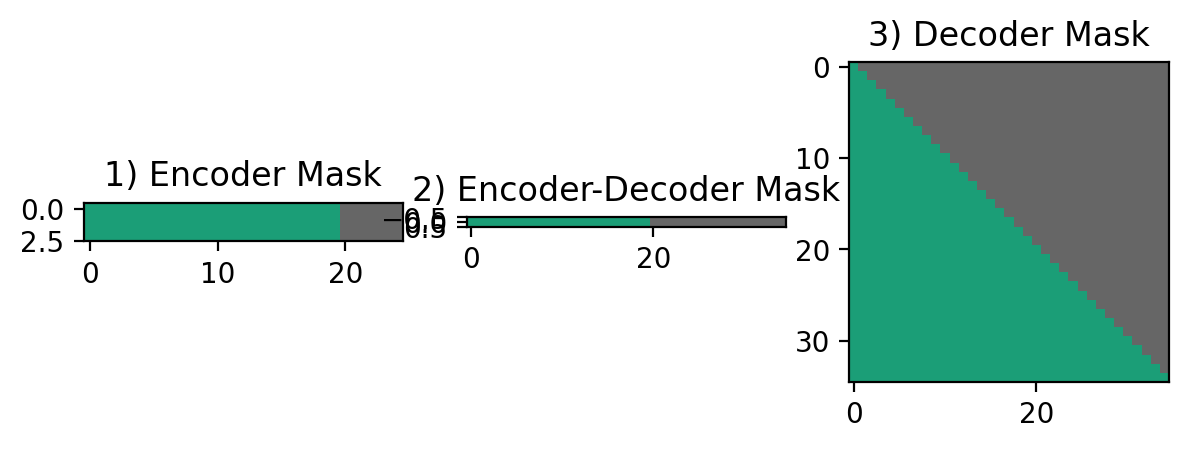

In [18]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

In [19]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


# 번역기 만들기

노드에 있는 걸로 하다가 에러가 있어서 번역기 부터는 퍼실님이 수정해주신 파일을 넣어서 돌려봤습니다.

In [62]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.7.1+cu118 | device: cuda


In [23]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data
!gzip -d ~/work/transformer/data/korean-english-park.train.tar.gz
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar

--2026-05-13 08:41:21--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-13 08:41:22--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘/home/jovyan/work/transformer/data/korean-e

In [63]:
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /home/jovyan/work/transformer/data
kor: True eng: True


### 데이터 정제 , 토큰화

In [80]:
def preprocess_sentence(sentence: str) -> str:
    # 영어 소문자로 바꾸고 양끝 공백 제거하기
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence) # 부호 앞에 공배 넣어서 단어랑 분리하기
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence) # 영어, 한글, 기호 제외하고는 공백으로 바꾸기
    sentence = re.sub(r"\s+", " ", sentence).strip() # 여러개 공백 하나로 줄이고 양끝 공백 제거
    return sentence

# 한국어 영어 쌍 불러오고 중복제거하기
def load_pairs(kor_path, eng_path):
    # 각각 파일 읽어서 리스트에 담기
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    # 한국어랑 영어 개수 맞는지 확인
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        # 중복된 문장이면 건너뛰기
        if key in seen:
            continue
        # 처음보는 문장이면 추가하고 전처리해서 저장하기
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])
# 말뭉치 분리하기 한국어뭉칭, 영어뭉치
kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [81]:
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    # 말뭉치 텍스트 파일로 저장 센텐스피스가 읽을 수 있게
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos") #영어 사전에는 앞뒤 자동으로 bos, eow 번호 붙이게 설정

# 결과 확인하기
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


) Updating active symbols. max_freq=12564 min_freq=1020
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=10114 size=120 all=7501 active=2242 piece=her
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=8413 size=140 all=8936 active=3677 piece=igh
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=7005 size=160 all=9829 active=4570 piece=ies
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=6070 size=180 all=10991 active=5732 piece=▁rep
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=5609 size=200 all=12149 active=6890 piece=ary
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=5598 min_freq=893
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4835 size=220 all=13041 active=1836 piece=ost
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4251 size=240 all=13831 active=2626 piece=▁say
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3983 size=260 all=14415 active=3210 piece=ans
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=3686 size=280 all=15044 active=3839 piece=▁which
bpe_mod

위에 너무 길게 나와서 보기 편하게 다시 적음

In [83]:
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


In [86]:
# 문장의 최대 크기 정하기
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
# 한국어, 영어 뭉치에서 하나씩 짝지어서 꺼내기
for k, e in zip(kor_corpus, eng_corpus):
    # 한국어, 영어 문장 번호로 바꾸기 
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함

    # 문장길이 제한하기 한국어는 1자 이상 40자 이하, 영어는 시작,끝 포함하니까 3자 이상 40자 이하로
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[1]), "tgt 예시 len:", len(tgt_corpus[1]))


학습용 병렬쌍: 58,876
src 예시 len: 26 tgt 예시 len: 34


In [97]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    # 문장 속 단어 위치 만들기
    position = np.arange(0, pos_len)[:, None]
    # 사인 코사인 함수로 계산하기
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    # 짝수에는 사인, 홀수에는 코사인 넣어서 고유 번호표 만들기
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    # 파이토치가 읽을 수 있게 변환하기
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))
        # 질문이랑 답변 매칭해서 점수 매기기
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        # 패딩은 점수 낮게 줘서 무시하기
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        # 중요도를 소프트맥스로 바꾸고 정보 곱해서 최종 결과 만들기
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        # 마지막에 정답 단어 후보 중 하나 고르는 층
        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        # 단어 숫자로 바꾸고 번호 붙이기
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)
        # 인코더가 입력 문장 분석
        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        # 디코더가 인코더 분석 결과랑 디코더 이전 답변 보고 다음 단어 생성
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


In [68]:
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)



def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask


In [69]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


In [70]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")


optimizer / scheduler / loss 준비 완료


In [74]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()


In [75]:
import time
import random
from tqdm.auto import tqdm

print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0

    batch_loop = tqdm(range(0, len(train_idx), BATCH_SIZE), 
                      desc=f"Epoch {epoch}/{EPOCHS}", 
                      leave=False)

    
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
        
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


학습 시작: 20 epochs, batch=128, 데이터 58,876 문장


Epoch 1/20:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch  1 | avg loss 5.4057 | lr 5.10e-04 | elapsed 57.3s


Epoch 2/20:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch  2 | avg loss 5.1282 | lr 6.24e-04 | elapsed 114.4s


...

Epoch 18 | avg loss 3.4755 | lr 6.29e-04 | elapsed 1029.3s


Epoch 19/20:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch 19 | avg loss 3.4358 | lr 6.14e-04 | elapsed 1086.4s


Epoch 20/20:   0%|          | 0/460 [00:00<?, ?it/s]

Epoch 20 | avg loss 3.3966 | lr 6.01e-04 | elapsed 1143.6s


In [115]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()
    # 입력된 한국어 문장 숫자로 바꾸기
    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    # 텐서로 만들고 차원 늘려서 맞춰주기(unsqueeze)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    # 입력 데이터 확인
    print(f" 입력 문장 Shape: {src.shape}") 
    print(f" 입력 번호들: {src_ids}")
    
    # 번역하는 시작인 bos 먼저 보내기
    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    #max len 만큰 한 단어씩 반복해서 찾기.
    for _ in range(max_len):
        # 만든 문장에 맞춰서 마스크 준비
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        # 다음 단어 후보 logits받기
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        # 마지막 단어 위치 결과만 뽑아옴
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피 모르는 단어는 고르지 않게함.
        # 제일 높은 점수 받은 단어 번호를 정답으로 고르기
        next_id = int(torch.argmax(next_logits).item())

        # 생성 과정 확인
        word = en_tokenizer.decode_ids([next_id])
        print(f"  Step {i+1} | 단어 ID: {next_id:5} | 단어: {word:10} | 현재까지 Shape: {out.shape}")

        
        # 문장 끝에 Eos가 나오면 멈추기
        if next_id == EOS_ID:
            break
            
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )
    # 숫자를 읽을 수 있는 영어 문장으로 바꿔서 반환
    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns

# 번역 결과만 보여주는 함수
def translate(sentence):
    result, *_ = evaluate(sentence)
    return result


In [116]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")


 Korean → English Translations
 입력 문장 Shape: torch.Size([1, 4])
 입력 번호들: [1233, 80, 132, 4]
  Step 2 | 단어 ID:    68 | 단어: he         | 현재까지 Shape: torch.Size([1, 1])
  Step 2 | 단어 ID:    81 | 단어: is         | 현재까지 Shape: torch.Size([1, 2])
  Step 2 | 단어 ID:     9 | 단어: the        | 현재까지 Shape: torch.Size([1, 3])
  Step 2 | 단어 ID:   362 | 단어: first      | 현재까지 Shape: torch.Size([1, 4])
  Step 2 | 단어 ID:   231 | 단어: president  | 현재까지 Shape: torch.Size([1, 5])
  Step 2 | 단어 ID:    33 | 단어: to         | 현재까지 Shape: torch.Size([1, 6])
  Step 2 | 단어 ID:   711 | 단어: play       | 현재까지 Shape: torch.Size([1, 7])
  Step 2 | 단어 ID:    15 | 단어: .          | 현재까지 Shape: torch.Size([1, 8])
  Step 2 | 단어 ID:     2 | 단어:            | 현재까지 Shape: torch.Size([1, 9])
 1. KO: 오바마는 대통령이다.
    EN: he is the first president to play .
----------------------------------------------------------------------
 입력 문장 Shape: torch.Size([1, 7])
 입력 번호들: [1089, 54, 831, 3414, 343, 6817, 4]
  Step 3 | 단어 ID:     9 | 단어:

In [135]:
translate("나는 '아이펠'에서 공부하고 있습니다.")

 입력 문장 Shape: torch.Size([1, 9])
 입력 번호들: [1051, 362, 7426, 455, 44, 6846, 36, 546, 4]
  Step 11 | 단어 ID:   235 | 단어: i          | 현재까지 Shape: torch.Size([1, 1])
  Step 11 | 단어 ID:    26 | 단어: m          | 현재까지 Shape: torch.Size([1, 2])
  Step 11 | 단어 ID:  1624 | 단어: working    | 현재까지 Shape: torch.Size([1, 3])
  Step 11 | 단어 ID:    62 | 단어: on         | 현재까지 Shape: torch.Size([1, 4])
  Step 11 | 단어 ID:   664 | 단어: my         | 현재까지 Shape: torch.Size([1, 5])
  Step 11 | 단어 ID:  3658 | 단어: kids       | 현재까지 Shape: torch.Size([1, 6])
  Step 11 | 단어 ID:    15 | 단어: .          | 현재까지 Shape: torch.Size([1, 7])
  Step 11 | 단어 ID:     2 | 단어:            | 현재까지 Shape: torch.Size([1, 8])


'i m working on my kids .'

In [136]:
examples =["대한민국", "한국에는 다양한 사람이 살고 있다.", "나는 아이펠에서 공부하고 있습니다."]

for s in examples:
    print(f": {translate(s)}")
    print("-" * 70)

 입력 문장 Shape: torch.Size([1, 3])
 입력 번호들: [107, 6965, 6844]
  Step 11 | 단어 ID:   365 | 단어: south      | 현재까지 Shape: torch.Size([1, 1])
  Step 11 | 단어 ID:   280 | 단어: korea      | 현재까지 Shape: torch.Size([1, 2])
  Step 11 | 단어 ID:     2 | 단어:            | 현재까지 Shape: torch.Size([1, 3])
: south korea
----------------------------------------------------------------------
 입력 문장 Shape: torch.Size([1, 7])
 입력 번호들: [190, 211, 2465, 1669, 1890, 22, 4]
  Step 11 | 단어 ID:    29 | 단어: in         | 현재까지 Shape: torch.Size([1, 1])
  Step 11 | 단어 ID:   365 | 단어: south      | 현재까지 Shape: torch.Size([1, 2])
  Step 11 | 단어 ID:   280 | 단어: korea      | 현재까지 Shape: torch.Size([1, 3])
  Step 11 | 단어 ID:    16 | 단어: ,          | 현재까지 Shape: torch.Size([1, 4])
  Step 11 | 단어 ID:   377 | 단어: there      | 현재까지 Shape: torch.Size([1, 5])
  Step 11 | 단어 ID:   154 | 단어: are        | 현재까지 Shape: torch.Size([1, 6])
  Step 11 | 단어 ID:     5 | 단어: a          | 현재까지 Shape: torch.Size([1, 7])
  Step 11 | 단어 ID:  1705 | 